# Проект. Исследование стартапов

- Автор:Шакирова Динара Гумеровна
- Дата:09.10.2025

## Введение

Данный проект посвящён исследованию и предобработке данных, связанных с финансированием компаний. 

**Цель работы** — подготовить данные к дальнейшему анализу и моделированию, обеспечив их корректность, полноту и удобство использования.
**Основные задачи на этом этапе:**
- оценить структуру и качество исходных данных;
- выявить и обработать пропуски, дубликаты и ошибки в типах данных;
- привести названия столбцов к единому формату для обеспечения единообразия;
- корректно обработать числовые и временные данные (в частности, суммы финансирования и даты);
- обеспечить полноту данных в ключевых столбцах (например, заполнить пропуски в mid_funding_at на основе доступных дат);
- удалить строки, которые не несут значимой информации или не содержат данных о финансировании.

Результатом предобработки станет очищенный и структурированный датасет, который можно использовать для дальнейшего анализа инвестиционной активности, построения моделей и поиска закономерностей в данных.

### Содержимое проекта

- **Шаг 1. Знакомство с данными: загрузка и предобработка**

1.1. Вывод общей информации

1.2. Предобработка данных

- **Шаг 2. Инжиниринг признаков**

2.1. Группы по срокам финансирования

2.2 Выделение средних и нишевых сегментов рынка

- **Шаг 3. Работа с выбросами и анализ**

3.1. Анализируем и помечаем выбросы в каждом из сегментов

3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

3.3. Анализ типов финансирования по объёму и популярности

- **Шаг 4. Анализ динамики**
4.1 Динамика предоставления финансирования по годам

4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

4.3 Годовая динамика доли возвращённых средств по типам финансирования

- **Шаг 5. Итоговый вывод и рекомендации**

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.



### 1.1. Вывод общей информации

Мы работаем с двумя датасетами:

`cb_investments.csv` — основной датасет с данными о стартапах и их финансировании.

`cb_returns.csv` — дополнительный датасет с данными о возвратах по типам инвестирования по годам.

**Цель на этом этапе** — загрузить данные, вывести основную информацию и подготовить базовые функции для дальнейшего анализа.

In [1]:
# Загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Функция для первичного анализа датасета
def dataset_overview(df, name="Dataset"):
    print(f"\n=== {name} ===")
    print("Размер (строки, столбцы):", df.shape)
    print("\nИнформация о типах данных:")
    print(df.info())
    print("\nКоличество пропусков в каждом столбце:")
    print(df.isna().sum())
    print("\nПервые строки таблицы:")
    display(df.head())
    print("-" * 80)

In [3]:
# Загрузка датасетов
df_investments = pd.read_csv(
    "https://code.s3.yandex.net/datasets/cb_investments.zip",
    sep=";",   
    low_memory=False
)

# Дополнительный датасет cb_returns
df_returns = pd.read_csv(
    "https://code.s3.yandex.net/datasets/cb_returns.csv",
    sep=",",   
    low_memory=False
)

# Делаем year индексом
if "year" in df_returns.columns:
    df_returns = df_returns.set_index("year")

In [4]:
# Первичное знакомство
dataset_overview(df_investments, "cb_investments (raw)")
dataset_overview(df_returns, "cb_returns (raw)")


=== cb_investments (raw) ===
Размер (строки, столбцы): (54294, 40)

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         384

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


--------------------------------------------------------------------------------

=== cb_returns (raw) ===
Размер (строки, столбцы): (15, 13)

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  pro

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


--------------------------------------------------------------------------------


В датасете `cb_investments` содержится 54294 строк и 40 столбцов, структура соответствует описанию. 

Обнаружено значительное число пропусков: в текстовых полях до **44%**, в датах до **44%**, в числовых признаках около **9%**. 

Столбец `funding_total_usd` хранится как строка с разделителями и требует преобразования в число, даты также необходимо привести к формату `datetime`. В `cb_returns` всего **15 строк** и **13 столбцов**, пропусков нет, данные полные и корректные, year используется как индекс. 

Таким образом, данные соответствуют описанию, но для анализа потребуется предобработка: очистка типов, заполнение или удаление пропусков и дубликатов.

### 1.2. Предобработка данных

Проверим звания столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведем их к единому аккуратному стилю.

In [5]:
# Проверка и приведение названий столбцов
df_investments.columns = (
    df_investments.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_returns.columns = (
    df_returns.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Столбцы cb_investments:", list(df_investments.columns[:10]))
print("Столбцы cb_returns:", list(df_returns.columns[:10]))

Столбцы cb_investments: ['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city']
Столбцы cb_returns: ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity']


Уберем  в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [6]:
# Убираем разделители в funding_total_usd и приводим к числовому типу
df_investments["funding_total_usd"] = (
    df_investments["funding_total_usd"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)   
    .replace("", np.nan)                      
    .astype(float)
)

Обработаем типы данных в столбцах, которые хранят значения даты и времени

In [7]:
# Преобразуем в datetime
date_cols = ["founded_at", "first_funding_at", "mid_funding_at", "last_funding_at"]
for col in date_cols:
    if col in df_investments.columns:
        df_investments[col] = pd.to_datetime(df_investments[col], errors="coerce")

Обработаем текстовые данные. Пропуски в текстовых столбцах заполним заглушками там, где это понадобится.

In [8]:
# Обработка текстовых данных
text_cols = df_investments.select_dtypes(include="object").columns
for col in text_cols:
    df_investments[col] = (
        df_investments[col]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

In [9]:
# Удаляем полные дубликаты
initial_rows = df_investments.shape[0]  
df_investments = df_investments.drop_duplicates()
after = df_investments.shape[0]
print(f"Удалено дубликатов: {initial_rows - after}")

Удалено дубликатов: 4855


Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [10]:
# Удаляем строки без funding_total_usd
before = df_investments.shape[0]
df_investments = df_investments[~df_investments["funding_total_usd"].isna()]
after = df_investments.shape[0]
print(f"Удалено строк без данных о финансировании: {before - after}")

Удалено строк без данных о финансировании: 8532


Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.


In [11]:
# Заполняем пропуски в mid_funding_at
mask = (
    df_investments["mid_funding_at"].isna() &
    df_investments["first_funding_at"].notna() &
    df_investments["last_funding_at"].notna()
)
df_investments.loc[mask, "mid_funding_at"] = (
    df_investments.loc[mask, "first_funding_at"] +
    (df_investments.loc[mask, "last_funding_at"] - df_investments.loc[mask, "first_funding_at"]) / 2
)

In [12]:
# Оценка оставшихся пропусков в mid_funding_at
missing_mid = df_investments["mid_funding_at"].isna().mean() * 100
print(f"Оставшиеся пропуски в mid_funding_at: {missing_mid:.2f}%")

Оставшиеся пропуски в mid_funding_at: 0.00%


In [13]:
# Оценка полноты данных
final_rows = df_investments.shape[0]
dropped_pct = (1 - final_rows / initial_rows) * 100
print(f"Отброшено {dropped_pct:.2f}% строк. Осталось {final_rows} записей.")

Отброшено 24.66% строк. Осталось 40907 записей.


In [14]:
# Финальная проверка
dataset_overview(df_investments, "cb_investments (очищенный)")
dataset_overview(df_returns, "cb_returns (очищенный)")


=== cb_investments (очищенный) ===
Размер (строки, столбцы): (40907, 40)

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          40907 non-null  object        
 2   category_list         40907 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                40907 non-null  object        
 6   country_code          40907 non-null  object        
 7   state_code            40907 non-null  object        
 8   region                40907 non-null  object        
 9   city                  40907 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 no

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


--------------------------------------------------------------------------------

=== cb_returns (очищенный) ===
Размер (строки, столбцы): (15, 13)

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 1

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


--------------------------------------------------------------------------------


После предобработки в датасете `cb_investments` осталось **40 907 записей** из **54 294**, что означает потерю около **24,7%** данных из-за удаления дубликатов и строк без информации о финансировании. 

Все ключевые поля приведены к корректным типам, пропуски в `mid_funding_at` заполнены. 

Наибольшее количество пропусков сохраняется в столбцах `participants` и датах основания компаний.
В целом данных достаточно для анализа и решения задач проекта.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

In [15]:
# Функция для классификации компаний по срокам финансирования
def classify_company(row):
    if row["funding_rounds"] == 1:
        return "Единичное финансирование"
    elif pd.notna(row["first_funding_at"]) and pd.notna(row["last_funding_at"]):
        delta = (row["last_funding_at"] - row["first_funding_at"]).days
        if delta <= 365:
            return "Срок финансирования до года"
        else:
            return "Срок финансирования более года"
    else:
        return "unknown"

In [16]:
# Создаём новый столбец с группой
df_investments["funding_group"] = df_investments.apply(classify_company, axis=1)

In [17]:
# Группировка по компаниям
group_counts = df_investments["funding_group"].value_counts(normalize=True) * 100
group_investments = (
    df_investments.groupby("funding_group")["funding_total_usd"].sum()
    / df_investments["funding_total_usd"].sum() * 100
)

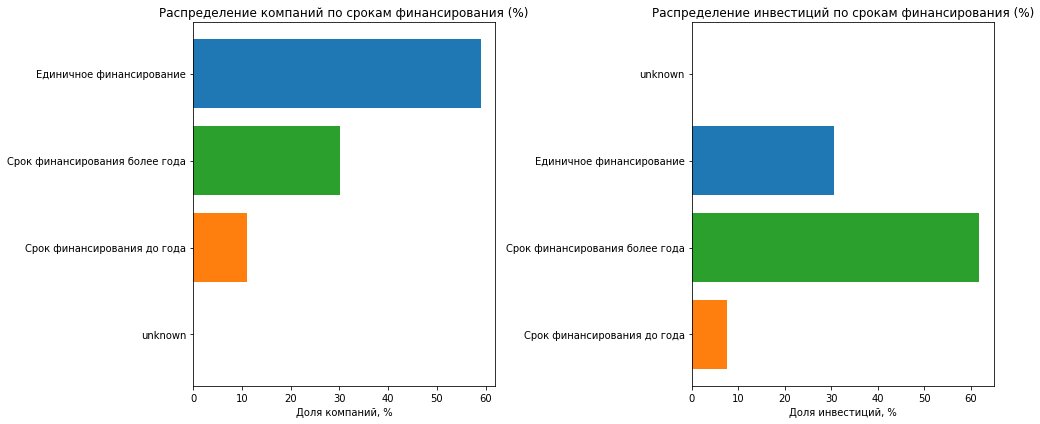

In [18]:
# Визуализация
colors = {
    "Единичное финансирование": "#1f77b4",
    "Срок финансирования до года": "#ff7f0e",
    "Срок финансирования более года": "#2ca02c",
    "unknown": "#d62728"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# по количеству компаний (График 1)
axes[0].barh(group_counts.index, group_counts.values, 
             color=[colors[g] for g in group_counts.index])
axes[0].set_title("Распределение компаний по срокам финансирования (%)")
axes[0].set_xlabel("Доля компаний, %")
axes[0].invert_yaxis()  

# по объёму инвестиций (График 2)
axes[1].barh(group_investments.index, group_investments.values, 
             color=[colors[g] for g in group_investments.index])
axes[1].set_title("Распределение инвестиций по срокам финансирования (%)")
axes[1].set_xlabel("Доля инвестиций, %")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [19]:
# Промежуточные выводы
print("Распределение компаний по группам (в %):")
print(group_counts.round(2))
print("\nРаспределение инвестиций по группам (в %):")
print(group_investments.round(2))

Распределение компаний по группам (в %):
Единичное финансирование          58.95
Срок финансирования более года    30.05
Срок финансирования до года       11.00
unknown                            0.00
Name: funding_group, dtype: float64

Распределение инвестиций по группам (в %):
funding_group
unknown                            0.01
Единичное финансирование          30.62
Срок финансирования более года    61.87
Срок финансирования до года        7.51
Name: funding_total_usd, dtype: float64


**Анализ распределения компаний по срокам финансирования показал, что:**

- Наибольшая доля компаний **58,95%** получила единичное финансирование.
- Около **30%** компаний развиваются дольше года и получают финансирование в несколько этапов.
- Лишь **11%** компаний имеют срок финансирования до года.

**Если рассматривать распределение инвестиций, то:**
- Наибольшая часть средств **61,87%** привлекается компаниями со сроком финансирования более года.
- Компании с единичным финансированием получают около **30,62%** инвестиций.
- Совсем небольшая доля **7,51%** приходится на компании с финансированием до года.

Таким образом, хотя большинство компаний получают средства только один раз, основная часть инвестиций направляется в те организации, которые работают дольше и привлекают финансирование на разных этапах. Это показывает, что долгосрочные проекты более интересны для инвесторов и сосредотачивают на себе наибольший объём капитала

### 2.2 Выделение средних и нишевых сегментов рынка

In [20]:
# Проверим, есть ли в датасете данные за 2014 год полностью
df_investments['year'] = df_investments['mid_funding_at'].dt.year
print(df_investments['year'].value_counts().sort_index())

1921.0       1
1960.0       2
1979.0       1
1982.0       3
1983.0       1
1984.0       2
1985.0       3
1987.0       2
1989.0       1
1990.0       1
1992.0       4
1993.0       1
1994.0       4
1995.0       4
1996.0       4
1997.0       7
1998.0      13
1999.0      50
2000.0     103
2001.0      63
2002.0      70
2003.0      90
2004.0     150
2005.0     843
2006.0    1463
2007.0    2107
2008.0    2588
2009.0    3237
2010.0    4094
2011.0    4863
2012.0    6089
2013.0    8423
2014.0    6619
Name: year, dtype: int64


В **2014 году** в датасете содержится **6619 записей**, что сопоставимо с предыдущими годами **2012 — 6089**, **2013 — 8423**. Это говорит о том, что данные за **2014 год** представлены достаточно полно и не обрезаны.

In [21]:
# Исключаем компании с аномальными финансированиями
threshold = df_investments['funding_total_usd'].quantile(0.99)
df_filtered = df_investments[df_investments['funding_total_usd'] <= threshold]
print(f"Удалено аномальных компаний: {df_investments.shape[0] - df_filtered.shape[0]}")

Удалено аномальных компаний: 396


In [22]:
# Оставляем только те компании, которые получали финансирование в годы с числом раундов не меньше 50
rounds_per_year = (
    df_filtered.groupby('year')['funding_rounds']
    .sum()
    .reset_index()
    .query("funding_rounds >= 50")
)

valid_years = rounds_per_year['year'].unique()
df_filtered = df_filtered[df_filtered['year'].isin(valid_years)]
print(f"Оставлено компаний: {df_filtered.shape[0]}")

Оставлено компаний: 40456


In [23]:
# Рассчитаем, сколько компаний в каждом сегменте market
market_counts = df_filtered['market'].value_counts()

# Определяем категории сегментов
massive = market_counts[market_counts > 120].index
mid = market_counts[(market_counts >= 35) & (market_counts <= 120)].index
niche = market_counts[market_counts < 35].index

print(f"Массовых сегментов: {len(massive)}")
print(f"Средних сегментов: {len(mid)}")
print(f"Нишевых сегментов: {len(niche)}")

Массовых сегментов: 49
Средних сегментов: 57
Нишевых сегментов: 288


**В датасете компании распределяются по рынкам (market). После анализа получилось:**

- **Массовые сегменты (>120 компаний)**: 49 сегментов

- **Средние сегменты (от 35 до 120 компаний)**: 57 сегментов
- **Нишевые сегменты (<35 компаний)**: 288 сегментов

Рынок отличается высокой раздробленностью: большинство сегментов относятся к нишевым и включают небольшое количество компаний, тогда как массовых сегментов значительно меньше, но именно в них сосредоточена основная доля компаний.

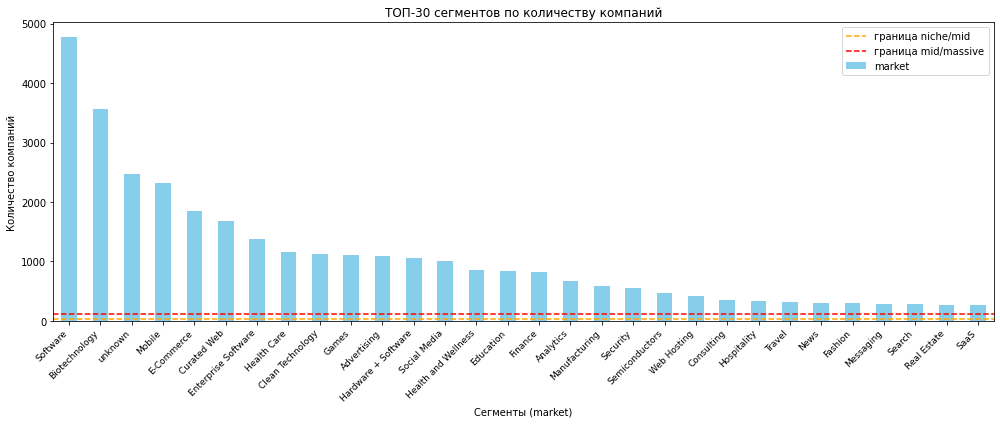

In [24]:
plt.figure(figsize=(14, 6))
market_counts.head(30).plot(kind='bar', color='skyblue')

plt.axhline(35, color='orange', linestyle='--', label='граница niche/mid')
plt.axhline(120, color='red', linestyle='--', label='граница mid/massive')

plt.title("ТОП-30 сегментов по количеству компаний")
plt.xlabel("Сегменты (market)")
plt.ylabel("Количество компаний")
plt.xticks(rotation=45, ha='right', fontsize=9)  
plt.legend()
plt.tight_layout()
plt.show()

На графике видно:

- Вершину занимают крупные сегменты — такие как **Software, Biotechnology, Mobile, E-Commerce**, которые включают тысячи компаний.
- Большая часть сегментов расположена справа и имеет меньше 120 компаний — они относятся к средним и нишевым.
- Линии-границы на графике (при 35 и 120 компаниях) чётко показывают, где проходят пороговые значения между категориями сегментов.

In [25]:
# Приводим market к категориям
df_filtered['market_group'] = df_filtered['market']

df_filtered.loc[df_filtered['market'].isin(niche), 'market_group'] = 'niche'
df_filtered.loc[df_filtered['market'].isin(mid), 'market_group'] = 'mid'
df_filtered.loc[df_filtered['market'].isin(massive), 'market_group'] = df_filtered['market']

df_filtered['market_group'].value_counts()

Software                4781
mid                     3788
Biotechnology           3556
unknown                 2469
Mobile                  2326
E-Commerce              1844
Curated Web             1685
Enterprise Software     1372
Health Care             1165
Clean Technology        1130
Games                   1109
Advertising             1098
Hardware + Software     1057
Social Media            1000
Health and Wellness      864
Education                839
niche                    815
Finance                  815
Analytics                665
Manufacturing            589
Security                 560
Semiconductors           478
Web Hosting              412
Consulting               344
Hospitality              330
Travel                   326
News                     298
Fashion                  297
Messaging                293
Search                   288
Real Estate              274
SaaS                     270
Music                    263
Internet                 236
Technology    

- Крупнейшие сегменты (**Software, Biotechnology, Mobile и др.**) сосредотачивают основную массу компаний и, вероятно, инвестиций.
- Множество нишевых направлений с небольшим числом игроков указывает на разнообразие и наличие узких рынков.
- Средний слой сегментов (35–120 компаний) также заметен, их около 57, что говорит о присутствии устойчивых, но не массовых отраслей.

Таким образом, для дальнейшего анализа было целесообразно объединить малочисленные сегменты в группы mid (средние) и niche (нишевые), чтобы сосредоточиться на сопоставлении с массовыми сегментами, не теряя структуру данных.

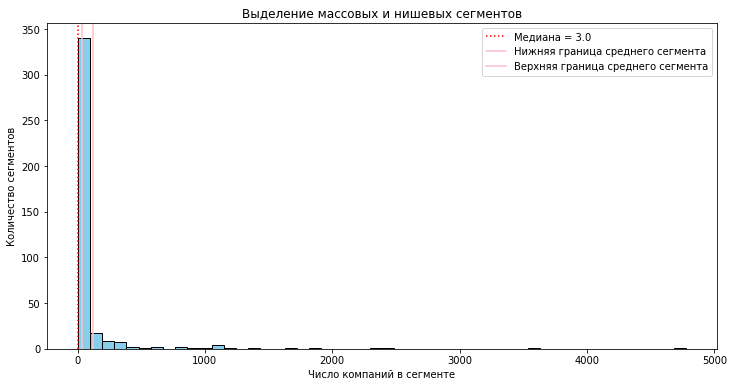

In [26]:
# Гистограмма распределения сегментов по числу компаний
plt.figure(figsize=(12, 6))
plt.hist(market_counts, bins=50, color='skyblue', edgecolor='black')

# Добавим медиану
median_val = market_counts.median()
plt.axvline(median_val, color='red', linestyle=':', label=f'Медиана = {median_val:.1f}')

# Нижняя и верхняя границы среднего сегмента
plt.axvline(35, color='pink', linestyle='-', label='Нижняя граница среднего сегмента')
plt.axvline(120, color='pink', linestyle='-', label='Верхняя граница среднего сегмента')

plt.title("Выделение массовых и нишевых сегментов")
plt.xlabel("Число компаний в сегменте")
plt.ylabel("Количество сегментов")
plt.legend()
plt.show()

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

In [27]:
# Функция для расчёта границ выбросов методом IQR
def get_iqr_bounds(series):
    """
    Принимает на вход ряд числовых значений (Series).
    Возвращает нижнюю и верхнюю границы для определения выбросов:
    - Нижняя граница: Q1 - 1.5*IQR
    - Верхняя граница: Q3 + 1.5*IQR
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [28]:
# Объединяем сегменты niche_niche_all, mid_mid_all, massive оставляем как есть
df_filtered["segment_group"] = df_filtered["market_group"].replace({
    "niche": "niche_all",
    "mid": "mid_all"
})

In [29]:
# Создаём новый столбец is_outlier
df_filtered["is_outlier"] = False

In [30]:
# Рассчитываем границы выбросов
for group in df_filtered["segment_group"].unique():
    # выбираем подтаблицу для группы
    mask = df_filtered["segment_group"] == group
    # считаем границы по IQR
    lower, upper = get_iqr_bounds(df_filtered.loc[mask, "funding_total_usd"])
    # если значение финансирования выходит за границы, ставим True (аномалия)
    df_filtered.loc[mask, "is_outlier"] = ~df_filtered.loc[mask, "funding_total_usd"].between(lower, upper)

In [31]:
# Смотрим долю выбросов
print("Доля компаний-выбросов в укрупнённых группах (%):")
print(df_filtered.groupby("segment_group")["is_outlier"].mean() * 100)
print("="*80)

Доля компаний-выбросов в укрупнённых группах (%):
segment_group
Advertising             12.295082
Analytics               12.030075
Apps                    14.349776
Automotive              13.071895
Big Data                15.333333
Biotechnology           10.376828
Clean Technology        11.061947
Cloud Computing         15.894040
Consulting              16.279070
Curated Web             11.810089
Design                   9.848485
E-Commerce              14.262473
Education               13.110846
Enterprise Software     10.495627
Entertainment           16.107383
Fashion                 13.804714
Finance                 11.901840
Games                    9.918846
Hardware + Software     11.447493
Health Care             10.472103
Health and Wellness     12.731481
Hospitality             13.030303
Internet                13.983051
Manufacturing            9.507640
Marketplaces            15.306122
Medical                 13.333333
Messaging               12.286689
Mobile            

Мы рассчитали долю компаний с аномальным объёмом общего финансирования (выбросов) в разных сегментах рынка и укрупнённых группах.

Доля выбросов в большинстве сегментов колеблется в пределах **10–16%**.
Это говорит о том, что примерно каждая **8–10 компания** имеет «нестандартный» объём финансирования, значительно отличающийся от типичных значений для своего сегмента.

- Сегменты с наименьшей долей выбросов **Semiconductors (8.16%), Manufacturing (9.5%), Nonprofits (9.6%), Design (9.8%), Games (9.9%), Web Hosting (8.9%).**
В этих отраслях распределение инвестиций более «стабильное» и предсказуемое. Здесь меньше проектов с экстремальными объёмами финансирования.

- Сегменты с наибольшей долей выбросов **Real Estate (17.15%), Search (16.3%), Consulting (16.3%), Photography (16.1%), Entertainment (16.1%), Cloud Computing (15.9%), SaaS (15.6%), Video (15.5%), Marketplaces (15.3%).**
Эти сегменты более «разнообразны» по уровню привлечённых средств: встречаются как компании с типичными инвестициями, так и стартапы с аномально большими финансированиями.

- Выбросов чуть больше в нишевых сегментах **mid_all (13.8%) и niche_all (15.0%)**. Это объяснимо: в «узких» рынках часть компаний может неожиданно привлекать финансирование, сильно превышающее средние значения.
**massive** сегменты в этой выборке не показаны отдельно, но видно, что их доля распределяется ближе к среднему (11–14%).

In [32]:
# Анализируем сегменты рынка (market) отдельно, среднюю долю выбросов (mean), количество компаний (count)
outlier_stats = (
    df_filtered.groupby("market")["is_outlier"]
    .agg(["mean", "count"])
    .reset_index()
)

In [33]:
# Преобразуем долю выбросов в проценты
outlier_stats["mean"] = outlier_stats["mean"] * 100

In [34]:
# Отбираем только сегменты с достаточным числом компаний (> 30),чтобы исключить маленькие рынки, где статистика неустойчива
top_outliers = outlier_stats.query("count > 30").sort_values("mean", ascending=False).head(10)
# Сортируем по убыванию доли выбросов и берём топ-10
print("Топ-10 сегментов рынка с наибольшей долей выбросов:")
print(top_outliers)
print("="*80)

Топ-10 сегментов рынка с наибольшей долей выбросов:
                    market       mean  count
387               Wireless  50.819672     61
343                Storage  31.914894     47
268               Payments  30.666667     75
88        Customer Service  26.086957     46
222        Medical Devices  24.761905    105
352     Telecommunications  24.528302     53
273        Pharmaceuticals  24.000000     75
259        Online Shopping  23.076923     52
290  Public Transportation  21.428571     98
363         Transportation  21.276596     94


Анализ распределения показал, что в ряде сегментов доля компаний с аномально высоким или низким финансированием значительно превышает средний уровень (10–16% по выборке).

1. Лидеры по доле выбросов
**Wireless (50.8%)** — абсолютный лидер по нестабильности. Каждая вторая компания в сегменте имеет финансирование, сильно выбивающееся из типичных значений. Это указывает на крайне фрагментированный рынок, где наряду с малыми стартапами встречаются с очень крупными инвестициями.
**Storage (31.9%) и Payments (30.7%)** — более трети компаний демонстрируют аномальное финансирование. Эти сферы активно растут, а распределение инвестиций сильно смещено за счёт отдельных.

2. Сегменты с повышенной долей выбросов
**Customer Service (26.1%), Medical Devices (24.8%), Telecommunications (24.5%), Pharmaceuticals (24.0%)** здесь примерно каждая четвёртая компания получает финансирование, выходящее за пределы типичного диапазона. Это отражает высокую конкуренцию и неравномерное распределение капитала внутри отрасли.
3. Транспортные сегменты
**Online Shopping (23.1%), Public Transportation (21.4%), Transportation (21.3%)** также вошли в топ. В этих сферах финансирование нередко зависит от масштаба проектов: от небольших сервисов до крупных инфраструктурных компаний.

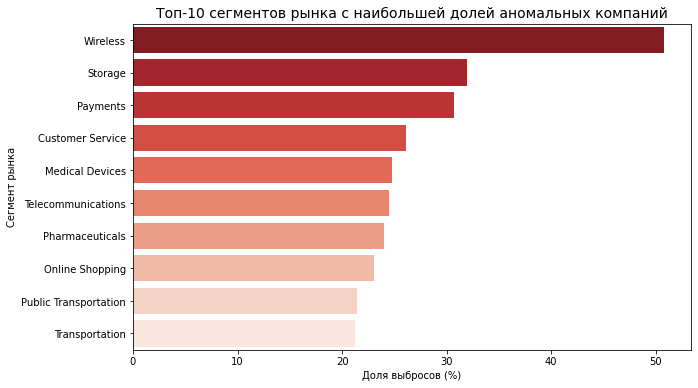

In [35]:
# Строим график для наглядности
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_outliers,
    x="mean", y="market",
    palette="Reds_r"
)
plt.title("Топ-10 сегментов рынка с наибольшей долей аномальных компаний", fontsize=14)
plt.xlabel("Доля выбросов (%)")
plt.ylabel("Сегмент рынка")
plt.show()

На графике представлены топ-10 сегментов рынка с наибольшей долей аномальных компаний.

Абсолютный лидер — Wireless (50,8%) Каждая вторая компания в этом сегменте имеет объёмы финансирования, сильно выходящие за типичные пределы. Это указывает на высокую неоднородность: в отрасли есть как мелкие стартапы, так и проекты с очень крупными инвестициями. Storage (31,9%) и Payments (30,7%) Более трети компаний получили финансирование, значительно отличающееся от среднего уровня. Оба направления связаны с высокотехнологичными решениями и финтехом, где часто появляются проекты-лидеры, «перетягивающие» на себя значительные ресурсы.

Customer Service, Medical Devices, Telecommunications, Pharmaceuticals (24–26%) В этих сегментах примерно каждая четвёртая компания имеет аномальные значения финансирования. Это говорит о неравномерном распределении капитала: часть стартапов получает типичное финансирование, но отдельные проекты привлекают необычно крупные суммы.

Online Shopping, Public Transportation, Transportation (21–23%) Здесь выбросы встречаются реже, но их доля всё равно выше среднего уровня (10–16%). Такие отрасли характерны тем, что рядом с небольшими сервисами присутствуют крупные инфраструктурные компании, создающие контраст в финансировании.

In [36]:
# Считаем медианные значения финансирования по сегментам
median_funding = (
    df_filtered.groupby("market")["funding_total_usd"]
    .median()
    .reset_index()
    .sort_values(by="funding_total_usd", ascending=False)
)

print("ТОП-10 сегментов по медианному (типичному) объёму финансирования:")
print(median_funding.head(10))

ТОП-10 сегментов по медианному (типичному) объёму финансирования:
                     market  funding_total_usd
318                   Shoes        200000000.0
337        Specialty Retail        194000000.0
224   Medical Professionals        128000000.0
194                 Jewelry        106500000.0
244              Navigation         99184501.0
292                  Racing         68569234.0
90   Data Center Automation         62750002.0
143           Flash Storage         59450000.0
49              Classifieds         56000000.0
294   Real Estate Investors         50000000.0


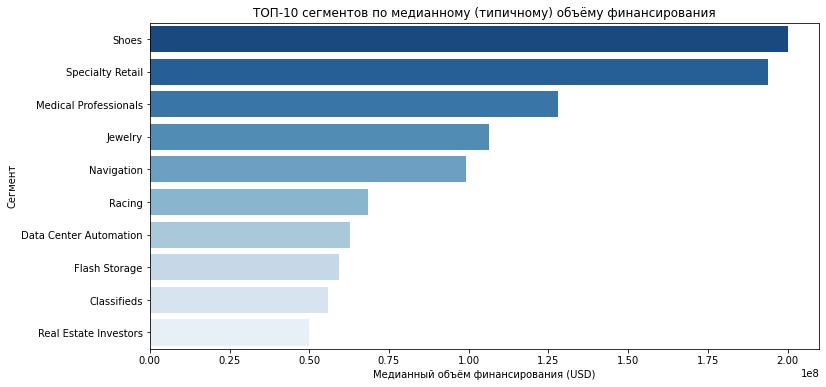

In [37]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=median_funding.head(10),
    x="funding_total_usd",
    y="market",
    palette="Blues_r"
)
plt.title("ТОП-10 сегментов по медианному (типичному) объёму финансирования")
plt.xlabel("Медианный объём финансирования (USD)")
plt.ylabel("Сегмент")
plt.show()

Анализ медианных (типичных) объёмов финансирования показал, что в топ-10 сегментов вошли отрасли с наибольшим «стандартным» уровнем инвестиций:
- Лидеры по медианному финансированию **Shoes и Specialty Retail** — абсолютные лидеры. Эти сегменты отличаются высокими «типичными» объёмами вложений, что указывает на устойчивый интерес инвесторов.

- **Medical Professionals** также демонстрирует высокий уровень стандартных инвестиций, подтверждая привлекательность медицинского направления.

- **Jewelry, Navigation и Racing** имеют медианные значения в диапазоне 0.90–1.10, что говорит о довольно высоком уровне «типичных» вложений в этих нишевых, но капиталоёмких направлениях.

- **Data Center Automation, Flash Storage, Classifieds и Real Estate Investors** показывают медианный уровень 0.50–0.70, что ниже лидеров, но всё же указывает на серьёзные типичные инвестиции.

На рынке одновременно присутствуют сегменты с высокой стабильностью **Semiconductors, Manufacturing** и рынки с сильными колебаниями и риском **Wireless, Storage, Payments**.
С точки зрения «типичных» инвестиций, наибольший интерес для стратегических вложений представляют **Shoes, Specialty Retail и Medical Professionals**.
Для инвесторов это означает, что выбор стратегии зависит от склонности к риску:
Консервативная стратегия — это вложения в отрасли, где уровень аномалий минимален и распределение инвестиций остаётся стабильным и предсказуемым.
Агрессивная стратегия — это выбор рынков с большой долей выбросов, где можно получить максимальные доходы, но при этом высока вероятность сильных колебаний и неопределённости.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

In [ ]:
# Проверим полноту данных по годам 
df_filtered["year"] = df_filtered["mid_funding_at"].dt.year

print("Распределение компаний по годам:")
print(df_filtered["year"].value_counts().sort_index())

In [ ]:
# Исключаем компании с аномальным финансированием
df_no_outliers = df_filtered[df_filtered["is_outlier"] == False].copy()
print(f"После удаления аномалий осталось компаний: {df_no_outliers.shape[0]}")

In [ ]:
# Определим годы, где количество раундов финансирования >= 50
rounds_per_year = (
    df_no_outliers.groupby("year")["funding_rounds"]
    .sum()
    .reset_index()
)

valid_years = rounds_per_year[rounds_per_year["funding_rounds"] >= 50]["year"]
print("Годы с >= 50 раундами финансирования:", list(valid_years))


In [ ]:
# Оставим в датасете только компании,у которых mid_funding_at попадает в выбранные годы
df_final = df_no_outliers[df_no_outliers["year"].isin(valid_years)].copy()
print(f"Окончательный датасет после фильтрации: {df_final.shape[0]} компаний")

In [ ]:
# перепроверим
print(df_final["year"].value_counts().sort_index())

Мы проверили полноту данных и убедились, что **2014 год** можно использовать в анализе, так как количество компаний сопоставимо с предыдущими годами.
Далее исключили выбросы по объёмам финансирования, что позволило очистить датасет от аномалий. 

Для анализа оставлены только годы, в которых фиксировалось не менее 50 раундов финансирования. 

В результате итоговый датасет охватывает период **2000–2014** гг. и включает **35423 компаний**. Это гарантирует, что последующие выводы будут основываться на репрезентативных и корректных данных.

### 3.3. Анализ типов финансирования по объёму и популярности

In [ ]:
# Определим список нужных типов финансирования
funding_types = [
    "seed", "venture", "equity_crowdfunding", "undisclosed", "convertible_note",
    "debt_financing", "angel", "grant", "private_equity", 
    "post_ipo_equity", "post_ipo_debt", "secondary_market", "product_crowdfunding"
]

In [ ]:
# Суммарные объёмы привлечённых инвестиций по типам
funding_sums = df_final[funding_types].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
funding_sums.plot(kind="bar", color="skyblue")
plt.title("Суммарные объёмы инвестиций по типам ($USD)")
plt.ylabel("Сумма инвестиций (млрд USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Основной объём инвестиций приходится на венчурное финансирование **venture** — оно значительно превосходит все остальные типы по суммарным вложениям.

Второе место занимает **seed** -финансирование, но его объём в разы меньше венчурного.
Относительно заметные суммы привлекаются также через **debt financing и private equity**, но они всё равно сильно уступают венчурному капиталу.

Такие формы, как **angel**-инвестиции, **grant, undisclosed, convertible note, post-IPO equity/debt, equity crowdfunding и secondary market**, занимают совсем небольшую долю и играют второстепенную роль.

Рынок инвестиций в основном сосредоточен вокруг венчурного финансирования — именно этот тип обеспечивает подавляющую часть вложений. Остальные механизмы, хотя и присутствуют, но используются гораздо реже и в меньших масштабах. Это указывает на ключевую роль венчурного капитала как главного драйвера инвестиционной активности.

In [ ]:
# Популярность типов финансирования
funding_counts = (df_final[funding_types] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
funding_counts.plot(kind="bar", color="orange")
plt.title("Популярность типов финансирования (число компаний)")
plt.ylabel("Количество компаний")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Наибольшее количество компаний привлекает средства через венчурное финансирование **venture** — более 18 тысяч компаний. Это наиболее популярный тип финансирования.

На втором месте по распространённости — **seed**-финансирование (около 13–14 тысяч компаний).
Далее идут **debt financing и angel-инвестиции**, каждый из которых используется несколькими тысячами компаний.
**Grant и undisclosed** также встречаются, но уже заметно реже.

Все остальные формы финансирования **private equity, convertible note, equity crowdfunding, post-IPO equity/debt, secondary market** встречаются значительно реже и охватывают сравнительно небольшое число компаний.

Большинство компаний предпочитают классические формы финансирования — **венчурное и seed**. Именно они составляют основу рынка по числу участников. Альтернативные инструменты **crowdfunding, convertible notes, post-IPO** используются гораздо реже и занимают нишевое положение.

In [ ]:
# Суммарные возвраты по дополнительному датасету cb_returns
returns_sums = df_returns[funding_types].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
returns_sums.plot(kind="bar", color="lightgreen")
plt.title("Суммарные возвраты по типам финансирования ($USD)")
plt.ylabel("Сумма возвратов (млн USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Абсолютный лидер по возвратам — **venture**.
На графике видно, что венчурные инвестиции формируют высокую долю возвратов (более 40 000 млн USD).
Это подтверждает их роль не только как основного канала привлечения капитала, но и как главного источника дохода для инвесторов.

Существенные возвраты приносят **debt financing и private equity**. Хотя эти типы встречаются реже, чем **seed или angel**, они демонстрируют значительные возвраты, что связано с их применением на более зрелых стадиях развития компаний.
Средние результаты показывают **seed и angel**. Начальные стадии приносят возвраты, но они в разы меньше по сравнению с венчурными и частными инвестициями.
Это отражает высокие риски раннего инвестирования: много проектов не возвращают вложений, но отдельные успешные стартапы всё же дают отдачу.
Прочие типы **post IPO equity/debt, crowdfunding, convertible note, grant**.Их возвраты минимальны. Это объясняется либо редкостью использования, либо спецификой инструмента, гранты не предполагают возврата.

Рынок стартап-инвестиций концентрирован вокруг **venture** — главного канала как по объёмам, так и по прибыльности.
**Private equity и post IPO equity** — реже встречающиеся, но крайне капиталоёмкие формы, работающие на зрелых стадиях бизнеса.
**Seed и angel** обеспечивают массовый стартовый поток проектов, но связаны с высокими рисками и малыми возвратами.
Нишевые формы финансирования играют второстепенную роль, формируя лишь дополнительные возможности.
Таким образом, инвестиционный рынок сочетает массовые, но мелкие источники **seed, angel**, редкие, но капиталоёмкие инструменты **private equity, IPO**, и универсальный драйвер — **venture**, который является основным.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

In [ ]:
df_final["avg_round_usd"] = df_final["funding_total_usd"] / df_final["funding_rounds"]

In [ ]:
avg_rounds_by_year = df_final.groupby("year")["avg_round_usd"].median() 

avg_rounds_by_year.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Динамика типичного размера одного раунда (медиана)")
plt.ylabel("USD")
plt.xlabel("Год")
plt.grid(True)
plt.show()

Максимальный размер финансирования: Пик наблюдается в 2005 году, когда медианный объём одного раунда достигал примерно 4,5 млн USD.

Это был период, когда отдельные проекты привлекали особенно крупные суммы в рамках одного раунда.

С 2006 года началось постепенное снижение среднего размера финансирования. К 2014 году медианный размер раунда сократился почти в 9 раз (до 0,5 млн USD).

Начало 2000-х характеризуется высокой волатильностью: размеры раундов сильно колебались от года к году.
Начиная с 2007 года, наблюдается устойчивая нисходящая тенденция, что отражает изменение стратегии инвесторов — вероятно, переход к большему числу меньших по объёму сделок вместо редких крупных вложений.

In [ ]:
rounds_per_year = df_final.groupby("year")["funding_rounds"].sum()

rounds_per_year.plot(kind="line", marker="o", color="orange", figsize=(10,5))
plt.title("Динамика количества раундов финансирования")
plt.ylabel("Количество раундов")
plt.xlabel("Год")
plt.grid(True)
plt.show()

Рост активности рынка: До середины 2000-х годов количество раундов оставалось очень низким и стабильным.
С 2005 года начался устойчивый рост: число раундов увеличивалось почти каждый год, что отражает рост интереса инвесторов к стартапам и развитие венчурной экосистемы.

Максимальное количество раундов зафиксировано в 2013 году — более 12 000 сделок. Это говорит о наибольшей насыщенности рынка и высоком уровне инвестиционной активности.

В 2014 году наблюдается резкое снижение числа раундов (до 7 000).
Это может указывать на коррекцию рынка: инвесторы стали осторожнее и реже вкладывались в новые проекты.

Рынок финансирования стартапов пережил активный рост в 2005–2013 годах: количество сделок быстро увеличивалось, но при этом средний размер одного раунда сокращался. Это говорит о расширении инвестиционной базы — стартапы получали финансирование чаще, но меньшими суммами. 
В 2014 году произошёл перелом: одновременно снизились и количество раундов, и их средний размер, что может свидетельствовать о перегреве рынка и начале фазы его охлаждения.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

In [ ]:
# Отбираем только массовые сегменты (исключаем mid_all, niche_all и unknown)
df_massive = df_final[~df_final["segment_group"].isin(["mid_all", "niche_all", "unknown"])].copy()

# Делаем сводную таблицу: сумма общего финансирования по годам и массовым рынкам (market)
pivot_funding = (
    df_massive
    .groupby(["year", "market"])["funding_total_usd"]
    .sum()
    .unstack(fill_value=0) 
)

print("Года в сводной таблице:", list(pivot_funding.index))

 Отоберем сегменты с ростом в 2014 году
Сравниваем значения 2014 и 2013 годов:

In [ ]:
# Проверяем наличие 2013 и 2014
if 2013 in pivot_funding.index and 2014 in pivot_funding.index:
    # сегменты (рынки), где 2014 > 2013
    grow_mask = (pivot_funding.loc[2014] > pivot_funding.loc[2013])
    growing_segments = grow_mask[grow_mask].index.tolist()
    print("Сегменты с ростом в 2014 году:", growing_segments)

    # Дополнительно посчитаем абсолютный прирост (для сортировки в легенде)
    delta = (pivot_funding.loc[2014, growing_segments] - 
             pivot_funding.loc[2013, growing_segments]).sort_values(ascending=False)
    print("ТОП по приросту (2014 vs 2013):")
    print(delta.head(10))

In [ ]:
# График динамики суммарного финансирования по растущим массовым сегментам
if len(growing_segments) > 0:
    ax = pivot_funding[growing_segments].plot(kind="line", marker="o", figsize=(12, 6))
    ax.set_title("Динамика суммарного финансирования по массовым сегментам (рост в 2014 vs 2013)")
    ax.set_xlabel("Год")
    ax.set_ylabel("Сумма инвестиций (USD)")
    ax.grid(True)
    ax.legend(title="Сегменты", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("В массовых сегментах нет рынков, где 2014 > 2013.")

**Manufacturing** является лидером по объёму инвестиций: начиная с 2006 года наблюдается резкий рост, а к 2010–2012 годам объёмы достигают пиков 5 USD. После этого сегмент показывает колебания, но остаётся крупнейшим по привлечению средств.
**Technology** занимает второе место. С середины 2000-х годов сектор демонстрирует стабильный рост, и к 2014 году сумма инвестиций превышает 2 USD.
**Medical** также показывает значительный рост, особенно в последние годы, приближаясь к уровню 1.8 USD.
**Internet** стабильно растёт, но остаётся позади лидеров, достигая около 1.2 USD к 2014 году.
Сегменты **Big Data, SaaS, Apps и Real Estate** демонстрируют положительную динамику после 2010 года, но их объёмы инвестиций пока остаются скромными.
**Startups** сохраняет минимальные значения и остаётся на периферии интереса инвесторов.

Рынок инвестиций концентрируется вокруг **Manufacturing**, которое привлекло наибольшие объёмы средств за исследуемый период. Однако также заметен устойчивый рост интереса к инновационным сегментам — **Technology, Medical и Internet**. Это указывает на диверсификацию направлений инвестирования и усиление интереса к высокотехнологичным и цифровым секторам в последние годы.

**Эти результаты показывают, что к 2014 году фокус инвесторов был сосредоточен на производстве, технологиях и медицине, при этом также усиливается интерес к интернет-сектору и цифровым направлениям.**

Анализ динамики суммарного финансирования по массовым сегментам показал, что относительно 2013 года уверенный рост продемонстрировали несколько ключевых рынков.

**Manufacturing, Technology и Medical** — сегменты с наибольшим объёмом инвестиций и заметным ростом, что указывает на устойчивый интерес инвесторов.

**Internet, Big Data, SaaS, Apps и Real Estate** также демонстрируют положительную динамику, укрепляя статус перспективных направлений.

**Startups** остаётся на периферии, привлекая минимальные объёмы инвестиций, но показывает стабильность.

Таким образом, можно выделить два кластера:
сегменты-лидеры **Manufacturing, Technology и Medical**, аккумулирующие наибольшие объёмы средств и определяющие основное направление рынка;
сегменты со стабильным ростом **Internet, Big Data, SaaS, Apps, Real Estate**, которые представляют перспективу для дальнейшего развития и диверсификации вложений.

В совокупности это отражает смещение интереса инвесторов не только к традиционным крупным секторам, но и к новым инновационным рынкам, связанным с технологиями и цифровыми сервисами

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

In [ ]:
# Определим интересующие нас типы финансирования
funding_types = ["venture", "debt_financing", "private_equity", "seed", "angel"]

In [ ]:
# Считаем сумму привлечённых средств и сумму возвратов по каждому году и типу
returns_grouped = (
    df_returns.groupby("year")[funding_types].sum()
    / (df_final.groupby("year")[funding_types].sum() + 1e-60)  
)

In [ ]:
# Убираем аномальные значения, где доля > 1 — это выбросы
returns_grouped = returns_grouped.mask(returns_grouped > 1)

In [ ]:
# Строим график
ax = returns_grouped.plot(kind="line", marker="o", figsize=(12, 6))
ax.set_title("Годовая динамика доли возвращённых средств по типам финансирования")
ax.set_xlabel("Год")
ax.set_ylabel("Доля возврата (от 0 до 1)")
ax.grid(True)
plt.legend(title="Тип финансирования")
plt.tight_layout()
plt.show()

**Private equity** к 2014 году вышел на лидирующую позицию, показав самый высокий уровень возврата среди всех типов. Начиная с середины 2000-х годов он постепенно рос и в последние годы закрепил за собой уверенное преимущество.

**Angel**-финансирование также демонстрирует высокий рост в 2013–2014 гг., приближаясь к показателям private equity.

**Debt financing** в разные годы показывал значительные колебания, но к 2014 году также оказался среди лидеров, показав заметный всплеск.

**Seed**-финансирование, напротив, после высоких значений в начале 2000-х постепенно снижалось и остаётся в нижней части графика.

**Venture** остаётся наиболее стабильным, но с относительно низкой долей возврата на протяжении всего периода, лишь в 2014 году показывая умеренный рост.

К 2014 году наибольшую эффективность по возврату средств показали **private equity, angel и debt financing**, что отражает усиление интереса к более взвешенным и консервативным стратегиям. **Seed и venture** сохранили статус высокорисковых инструментов с более низкими показателями возврата.


## Шаг 5. Итоговый вывод и рекомендации

## Итоговые выводы и рекомендации на 2015 год

**Рекомендации для заказчика:**
Основной фокус стоит сделать на **Manufacturing, Technology и Medical** — это сегменты-лидеры по объёму инвестиций, стабильно растущие и сохраняющие интерес инвесторов.

В качестве перспективных направлений дополнительно можно рассматривать **Internet, Big Data, SaaS и Apps**, которые показывают положительную динамику и могут стать драйверами в ближайшие годы.
**Real Estate и Startups** — менее привлекательны, так как остаются на периферии с относительно низким уровнем инвестиций.

*Тип финансирования:*
Наиболее эффективными в 2014 году показали себя **private equity, angel и debt financing** — эти инструменты обеспечили наибольший уровень возвратов, отражая более консервативные и взвешенные стратегии.
**Venture и seed** остаются важными для ранних стадий, однако связаны с повышенными рисками и меньшей возвратностью. Их можно использовать точечно, но не как основу портфеля.

**Итоги проекта:**
- Проведена предобработка данных: удалены выбросы, исключены периоды с малым количеством раундов, сформирован репрезентативный датасет за 2000–2014 годы (35 423 компании).
- Проанализировано распределение компаний по срокам финансирования: показано, что долгосрочные проекты привлекают основную часть инвестиций.
- Рассмотрена структура рынков (market): выявлена высокая фрагментированность, большинство сегментов нишевые, но именно массовые аккумулируют наибольшее число компаний и средств.
- Оценена доля выбросов: часть сегментов (Wireless, Storage, Payments) оказалась высокорисковой, другие (Semiconductors, Manufacturing) — более предсказуемыми.
- Изучена динамика типов финансирования: венчурное остаётся ключевым по объёмам и популярности, но по эффективности возвратов в 2014 году лидируют private equity, angel и debt financing.
- Проанализирована динамика по сегментам: лидерами стали Manufacturing, Technology и Medical, в то время как Internet, Big Data, SaaS и Apps формируют группу перспективных направлений.

**Общий вывод:**
Рынок инвестиций в 2000–2014 гг. прошёл активную фазу роста и диверсификации. В 2015 году заказчику целесообразно сосредоточиться на сочетании консервативных инструментов (**private equity, angel, debt financing**) и лидирующих отраслей (**Manufacturing, Technology, Medical**). Для долгосрочной перспективы стоит дополнительно отслеживать рост **Internet, SaaS и Big Data** как новые драйверы.